# problem 2

In [1]:
import sklearn
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
X_train, X_valid = X_train_full[:40000],X_train_full[40000:]
y_train, y_valid = y_train_full[:40000],y_train_full[40000:]

# pixel 0-1 range
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_test / 255.0

In [5]:
# model architecture 1 
model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
model.summary()

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       692,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 712,330 (2.72 MB)

 Trainable params: 712,330 (2.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3894 - loss: 1.6899 - val_accuracy: 0.5651 - val_loss: 1.2259
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6159 - loss: 1.0976 - val_accuracy: 0.6566 - val_loss: 0.9906
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6814 - loss: 0.9230 - val_accuracy: 0.6711 - val_loss: 0.9549
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7267 - loss: 0.7897 - val_accuracy: 0.6761 - val_loss: 0.9395
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7638 - loss: 0.6894 - val_accuracy: 0.6773 - val_loss: 0.9514
313/313 - 1s - 2ms/step - accuracy: 0.6754 - loss: 0.9672


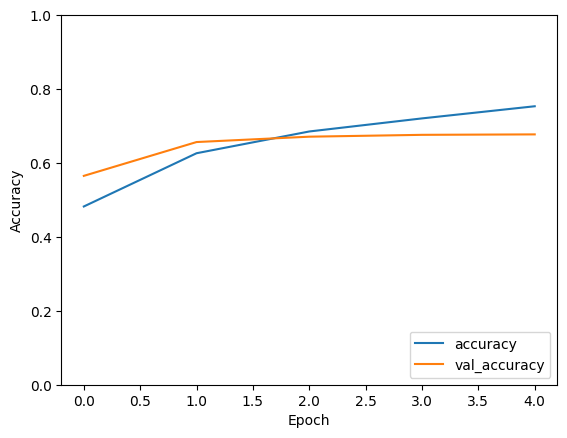

In [6]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


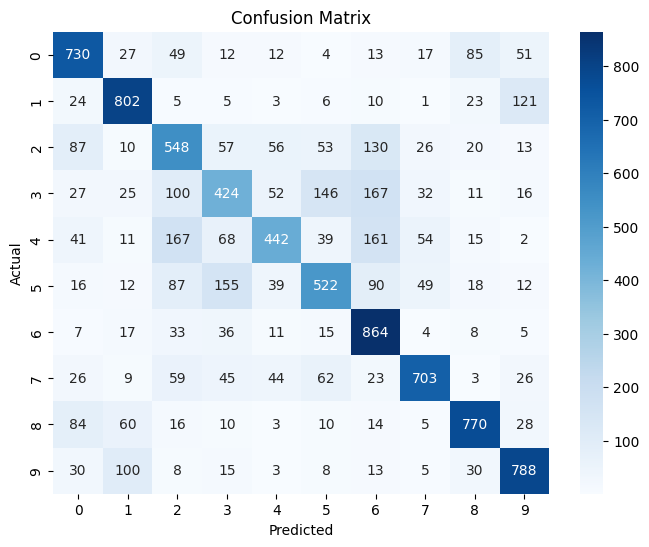

              precision    recall  f1-score   support

           0       0.68      0.73      0.70      1000
           1       0.75      0.80      0.77      1000
           2       0.51      0.55      0.53      1000
           3       0.51      0.42      0.46      1000
           4       0.66      0.44      0.53      1000
           5       0.60      0.52      0.56      1000
           6       0.58      0.86      0.70      1000
           7       0.78      0.70      0.74      1000
           8       0.78      0.77      0.78      1000
           9       0.74      0.79      0.76      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.65     10000
weighted avg       0.66      0.66      0.65     10000



In [6]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

In [7]:
# model architecture 2 (add convolution layer)
model1 = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3499 - loss: 1.7510 - val_accuracy: 0.5328 - val_loss: 1.3308
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5913 - loss: 1.1510 - val_accuracy: 0.6229 - val_loss: 1.0736
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6544 - loss: 0.9770 - val_accuracy: 0.6642 - val_loss: 0.9771
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7010 - loss: 0.8498 - val_accuracy: 0.6857 - val_loss: 0.9083
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7404 - loss: 0.7455 - val_accuracy: 0.6892 - val_loss: 0.9092
313/313 - 1s - 3ms/step - accuracy: 0.6836 - loss: 0.9215


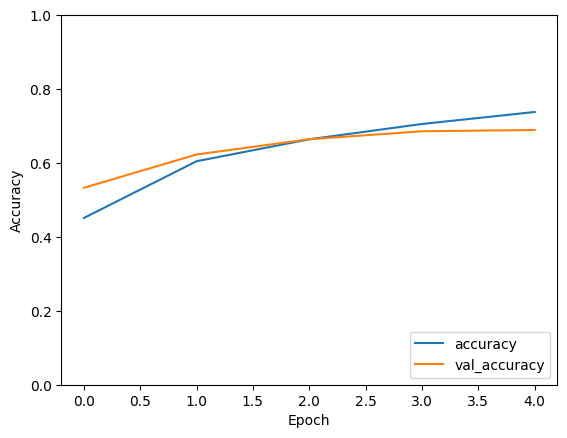

In [8]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model1.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model1.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


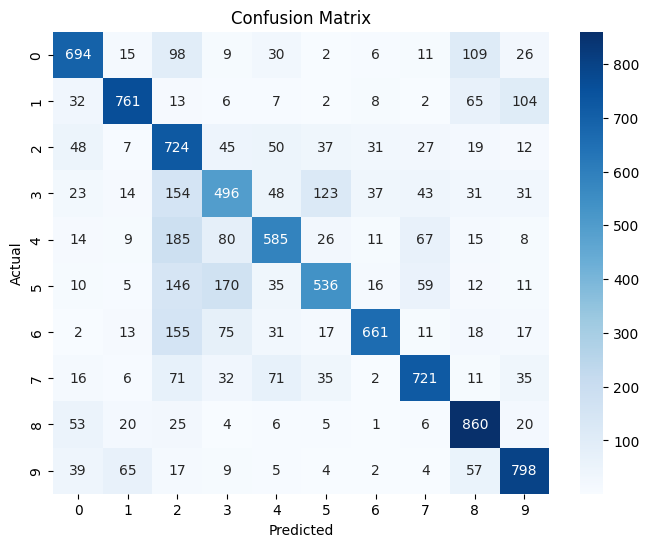

              precision    recall  f1-score   support

           0       0.75      0.69      0.72      1000
           1       0.83      0.76      0.79      1000
           2       0.46      0.72      0.56      1000
           3       0.54      0.50      0.52      1000
           4       0.67      0.58      0.63      1000
           5       0.68      0.54      0.60      1000
           6       0.85      0.66      0.74      1000
           7       0.76      0.72      0.74      1000
           8       0.72      0.86      0.78      1000
           9       0.75      0.80      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.70      0.68      0.69     10000
weighted avg       0.70      0.68      0.69     10000



In [9]:
y_pred = np.argmax(model1.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

In [9]:
# model architecture 3 (add convolution layer)
model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 13, 13, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,762 (3.28 MB)

 Trainable params: 858,762 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.3386 - loss: 1.7598 - val_accuracy: 0.5077 - val_loss: 1.4265
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5896 - loss: 1.1546 - val_accuracy: 0.6524 - val_loss: 0.9896
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6649 - loss: 0.9530 - val_accuracy: 0.6893 - val_loss: 0.8854
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7204 - loss: 0.8048 - val_accuracy: 0.6975 - val_loss: 0.8786
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7560 - loss: 0.7007 - val_accuracy: 0.7175 - val_loss: 0.8138
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7817 - loss: 0.6211 - val_accuracy: 0.7278 - val_loss: 0.7998
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8160 - loss: 0.5320 - val_accuracy: 0.7227 - val_loss: 0.8219
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8399 -

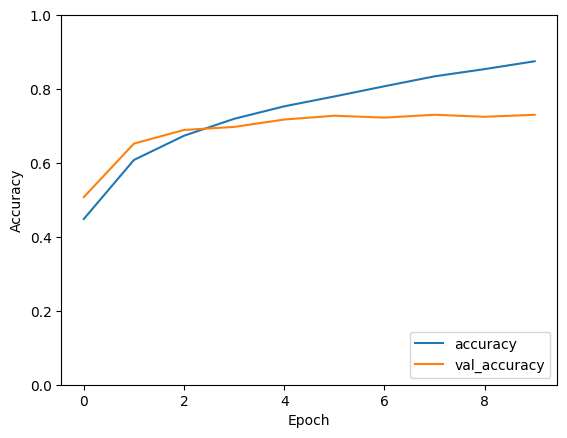

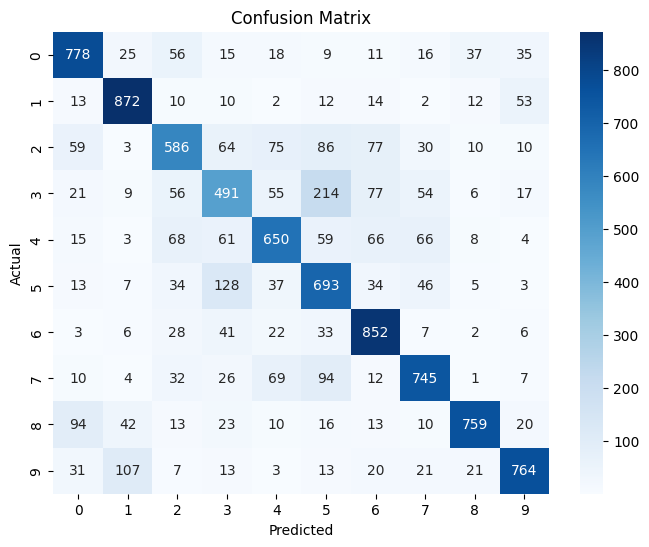

              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1000
           1       0.81      0.87      0.84      1000
           2       0.66      0.59      0.62      1000
           3       0.56      0.49      0.52      1000
           4       0.69      0.65      0.67      1000
           5       0.56      0.69      0.62      1000
           6       0.72      0.85      0.78      1000
           7       0.75      0.74      0.75      1000
           8       0.88      0.76      0.82      1000
           9       0.83      0.76      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



In [10]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

## hyperparameter tuning

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3395 - loss: 1.7711 - val_accuracy: 0.5116 - val_loss: 1.3406
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5654 - loss: 1.2206 - val_accuracy: 0.6004 - val_loss: 1.1155
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6410 - loss: 1.0252 - val_accuracy: 0.6348 - val_loss: 1.0276
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6843 - loss: 0.8971 - val_accuracy: 0.6552 - val_loss: 0.9849
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7198 - loss: 0.7990 - val_accuracy: 0.6834 - val_loss: 0.9110
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7483 - loss: 0.7182 - val_accuracy: 0.6979 - val_loss: 0.8846
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7775 - loss: 0.6364 - val_accuracy: 0.6968 - val_loss: 0.8826
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7978 - loss

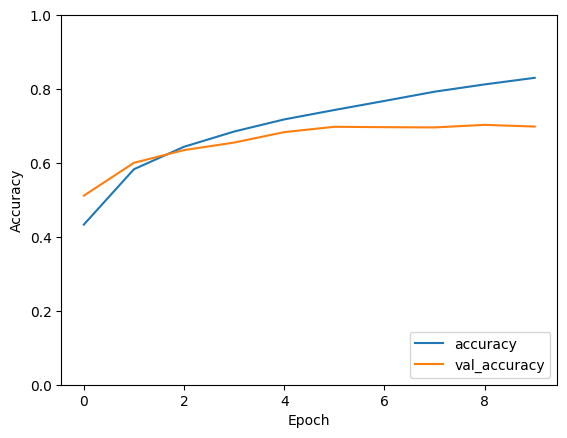

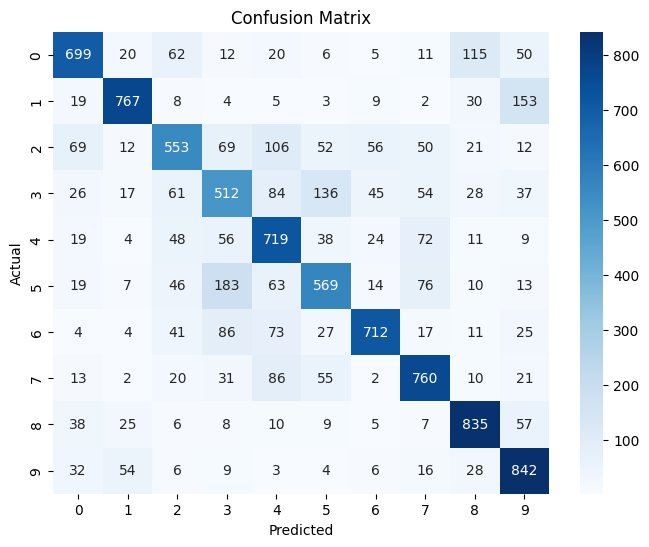

              precision    recall  f1-score   support

           0       0.75      0.70      0.72      1000
           1       0.84      0.77      0.80      1000
           2       0.65      0.55      0.60      1000
           3       0.53      0.51      0.52      1000
           4       0.62      0.72      0.66      1000
           5       0.63      0.57      0.60      1000
           6       0.81      0.71      0.76      1000
           7       0.71      0.76      0.74      1000
           8       0.76      0.83      0.80      1000
           9       0.69      0.84      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



In [10]:
# model2 = model1 + epochs 10
model2 = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model2.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model2.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model2.evaluate(X_test,  y_test, verbose=2)

y_pred = np.argmax(model2.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3459 - loss: 1.7787 - val_accuracy: 0.5381 - val_loss: 1.2997
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5709 - loss: 1.2122 - val_accuracy: 0.6073 - val_loss: 1.1178
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6372 - loss: 1.0328 - val_accuracy: 0.6450 - val_loss: 1.0238
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6844 - loss: 0.9153 - val_accuracy: 0.6503 - val_loss: 1.0065
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7118 - loss: 0.8152 - val_accuracy: 0.6938 - val_loss: 0.8931
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7431 - loss: 0.7391 - val_accuracy: 0.6947 - val_loss: 0.8941
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7719 - loss: 0.6597 - val_accuracy: 0.7101 - val_loss: 0.8541
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7914 - l

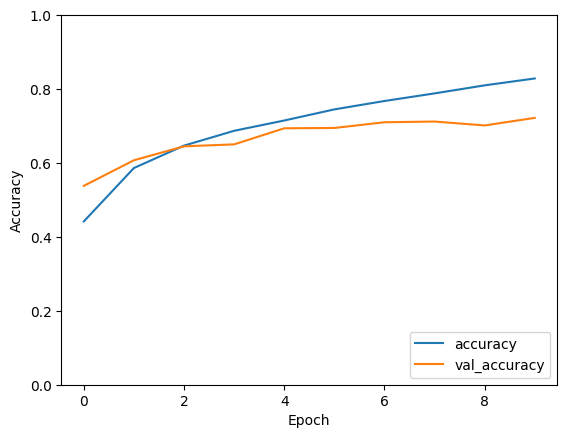

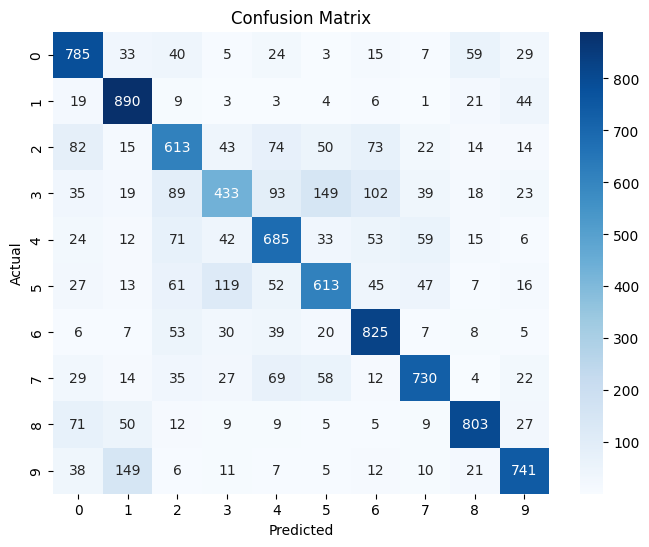

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1000
           1       0.74      0.89      0.81      1000
           2       0.62      0.61      0.62      1000
           3       0.60      0.43      0.50      1000
           4       0.65      0.69      0.67      1000
           5       0.65      0.61      0.63      1000
           6       0.72      0.82      0.77      1000
           7       0.78      0.73      0.76      1000
           8       0.83      0.80      0.82      1000
           9       0.80      0.74      0.77      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



In [12]:
# model3 = model2 + learning_rate 0.0005
model3 = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model3.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model3.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model3.evaluate(X_test,  y_test, verbose=2)

y_pred = np.argmax(model3.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3451 - loss: 1.7902 - val_accuracy: 0.5531 - val_loss: 1.2687
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5633 - loss: 1.2307 - val_accuracy: 0.5941 - val_loss: 1.1676
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6303 - loss: 1.0471 - val_accuracy: 0.6468 - val_loss: 1.0182
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6789 - loss: 0.9160 - val_accuracy: 0.6705 - val_loss: 0.9488
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7189 - loss: 0.8015 - val_accuracy: 0.6772 - val_loss: 0.9337
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7446 - loss: 0.7280 - val_accuracy: 0.6909 - val_loss: 0.9057
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7720 - loss: 0.6467 - val_accuracy: 0.7015 - val_loss: 0.8914
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8019 - loss: 0.5644 - 

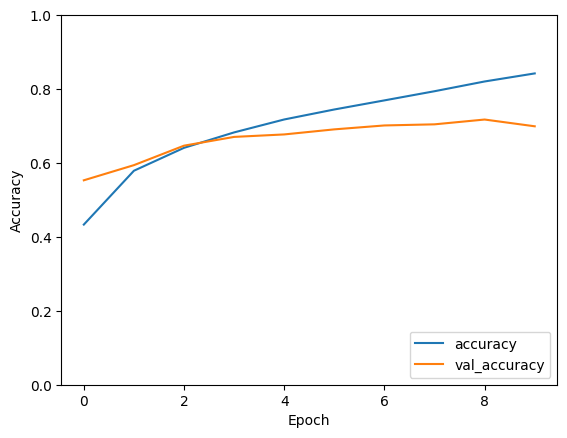

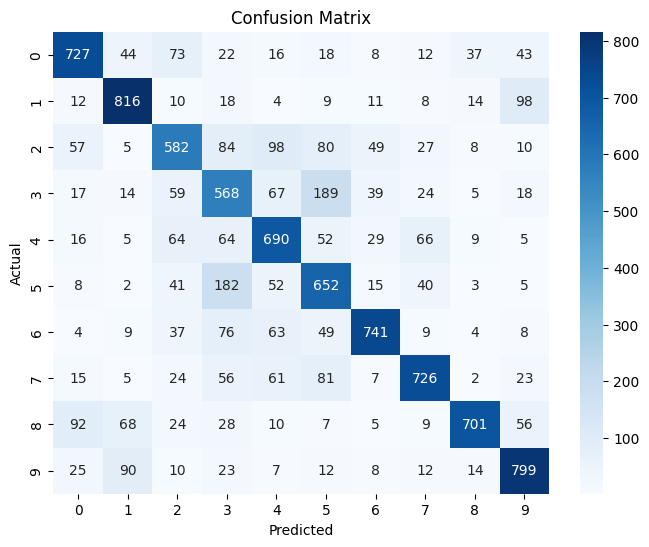

              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1000
           1       0.77      0.82      0.79      1000
           2       0.63      0.58      0.60      1000
           3       0.51      0.57      0.54      1000
           4       0.65      0.69      0.67      1000
           5       0.57      0.65      0.61      1000
           6       0.81      0.74      0.78      1000
           7       0.78      0.73      0.75      1000
           8       0.88      0.70      0.78      1000
           9       0.75      0.80      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



In [4]:
# model4 = model2 + batch_size 64
model4 = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model4.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model4.fit(X_train, y_train, epochs=10, batch_size = 64, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model4.evaluate(X_test,  y_test, verbose=2)

y_pred = np.argmax(model4.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4123 - loss: 1.6344 - val_accuracy: 0.5582 - val_loss: 1.2811
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5921 - loss: 1.1707 - val_accuracy: 0.6042 - val_loss: 1.1534
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6385 - loss: 1.0400 - val_accuracy: 0.6260 - val_loss: 1.0857
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6676 - loss: 0.9506 - val_accuracy: 0.6404 - val_loss: 1.0262
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6967 - loss: 0.8697 - val_accuracy: 0.6297 - val_loss: 1.0603
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7101 - loss: 0.8395 - val_accuracy: 0.6423 - val_loss: 1.0543
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7230 - loss: 0.8017 - val_accuracy: 0.6526 - val_loss: 1.0145
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7329 - los

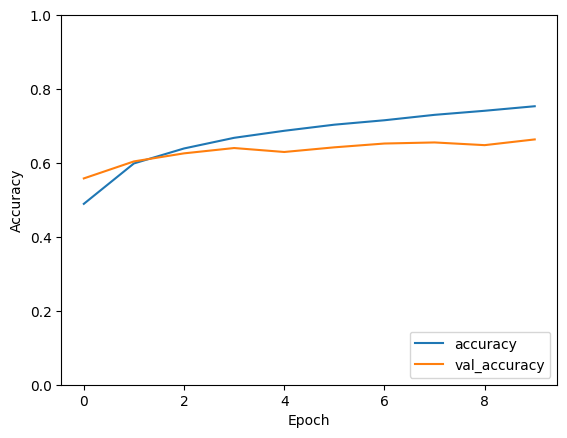

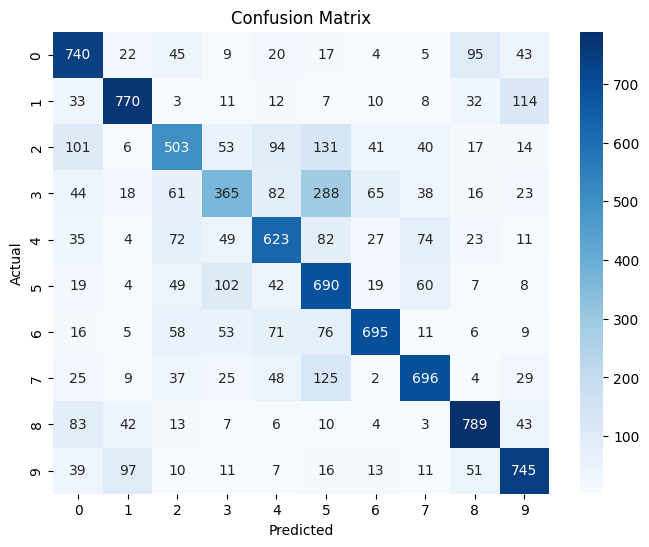

              precision    recall  f1-score   support

           0       0.65      0.74      0.69      1000
           1       0.79      0.77      0.78      1000
           2       0.59      0.50      0.54      1000
           3       0.53      0.36      0.43      1000
           4       0.62      0.62      0.62      1000
           5       0.48      0.69      0.57      1000
           6       0.79      0.69      0.74      1000
           7       0.74      0.70      0.72      1000
           8       0.76      0.79      0.77      1000
           9       0.72      0.74      0.73      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



In [16]:
# model5 = model2 + tanh function 
model5 = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='tanh', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='tanh'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='tanh'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model5.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model5.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model5.evaluate(X_test,  y_test, verbose=2)

y_pred = np.argmax(model5.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3446 - loss: 1.7884 - val_accuracy: 0.5169 - val_loss: 1.3816
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5792 - loss: 1.1845 - val_accuracy: 0.6382 - val_loss: 1.0330
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6678 - loss: 0.9547 - val_accuracy: 0.6731 - val_loss: 0.9451
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7113 - loss: 0.8278 - val_accuracy: 0.6762 - val_loss: 0.9495
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7552 - loss: 0.7128 - val_accuracy: 0.7140 - val_loss: 0.8676
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7874 - loss: 0.6116 - val_accuracy: 0.7051 - val_loss: 0.8826
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8142 - loss: 0.5401 - val_accuracy: 0.7152 - val_loss: 0.9716
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8406 - los

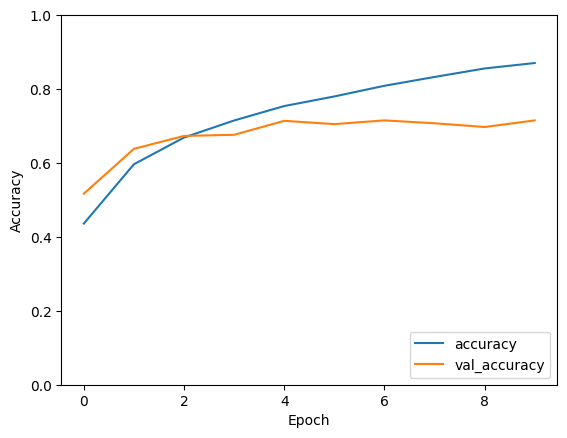

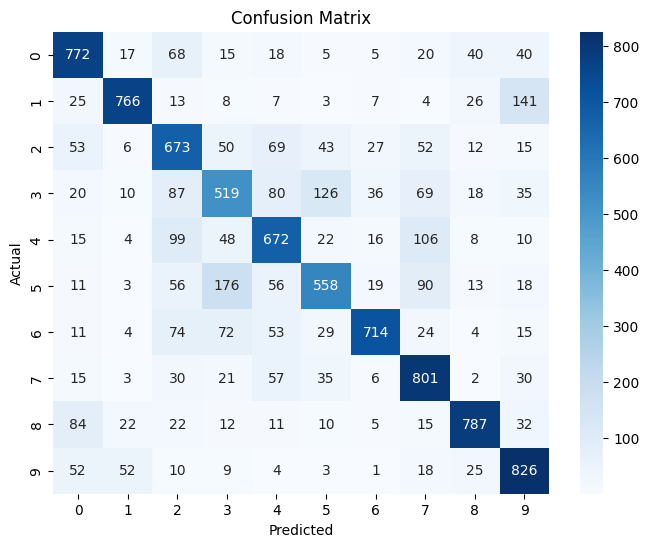

              precision    recall  f1-score   support

           0       0.73      0.77      0.75      1000
           1       0.86      0.77      0.81      1000
           2       0.59      0.67      0.63      1000
           3       0.56      0.52      0.54      1000
           4       0.65      0.67      0.66      1000
           5       0.67      0.56      0.61      1000
           6       0.85      0.71      0.78      1000
           7       0.67      0.80      0.73      1000
           8       0.84      0.79      0.81      1000
           9       0.71      0.83      0.76      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



In [5]:
# model6 = model2 + RMSprop function 
model6 = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)
model6.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model6.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model6.evaluate(X_test,  y_test, verbose=2)

y_pred = np.argmax(model6.predict(X_test), axis=1)
y_true = y_test.flatten()  

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(sklearn.metrics.classification_report(y_true, y_pred))